# Does the Kentucky Derby move the market — or the stock that runs it? 🐎📈
### The "Run for the Roses" folklore — a clean null, and one *t*-stat that only *looks* tradable

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sell_in_May%3F: Not_supported](https://img.shields.io/badge/Sell_in_May%3F-Not_supported-8b949e?style=flat-square)

Every year on the **first Saturday in May**, 150,000 people in big hats watch two minutes of horse racing, and every year a certain kind of market almanac asks the same two questions. First: is early May — Derby weekend, right on the "Sell in May and go away" line — a *market* seasonal? And second, more pointedly: does **Churchill Downs Inc. (`CHDN`)**, the company that literally owns and runs the Derby, get a bump around its own marquee event?

This is the cleanest possible test of sports-event folklore. Unlike Eurovision (where half the winners have no tradable stock), CHDN has traded since the 1990s — *full* price history, a stock with *direct* exposure. If there were anything here, this is exactly where it would show up.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the jackknife? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 26 Derbys hardcoded from Wikipedia (2020 was postponed to September — a named quirk). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kentucky_derby_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=10.0)
    INC = EV[EV["included"]]
    CHDN = INC[INC["leg"] == "chdn"]
    MKT = INC[INC["leg"] == "market"]
else:
    PRICES = EV = INC = CHDN = MKT = None
print("real cache present:", HAVE_REAL, "| Derbys:", len(data.EVENTS),
      "| CHDN events:", (0 if CHDN is None else len(CHDN)),
      "| market events:", (0 if MKT is None else len(MKT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 26, 'n_chdn': 26, 'n_market': 25, 'rows': 7166, 'start': '1998-01-02', 'fp': '4b4d7494b219', 'cost_bps': 10.0, 'ch_ru_mean': 0.359, 'ch_ru_t': 0.554, 'ch_ru_hit': 13, 'ch_ru_n': 26, 'ch_wk_mean': -0.063, 'ch_wk_t': -0.063, 'ch_wk_hit': 11, 'ch_wk_n': 26, 'ch_mo_mean': -0.195, 'ch_mo_t': -0.173, 'ch_mo_hit': 13, 'ch_mo_n': 26, 'ch_ru_cap_n': 0.159, 'ch_ru_cap_t': 0.245, 'ch_wk_cap_n': -0.003, 'ch_wk_cap_t': -0.003, 'ch_mo_cap_n': -0.091, 'ch_mo_cap_t': -0.08, 'mk_ru_mean': 0.003, 'mk_ru_t': 0.01, 'mk_ru_hit': 12, 'mk_ru_n': 25, 'mk_wk_mean': -0.617, 'mk_wk_t': -1.426, 'mk_wk_hit': 7, 'mk_wk_n': 25, 'mk_mo_mean': -0.319, 'mk_mo_t': -0.405, 'mk_mo_hit': 16, 'mk_mo_n': 25, 'mk_wk_cap_g': -0.602, 'mk_wk_cap_gt': -1.58, 'mk_wk_cap_n': -0.802, 'mk_wk_cap_t': -2.111, 'mk_wk_cap_n5': -0.702, 'mk_wk_cap_t5': -1.848, 'mk_mo_cap_n': -0.5, 'mk_mo_cap_t': -0.646, 'pl_ch_ru_p': 0.406, 'pl_ch_ru_plmean': 0.161, 'pl_ch_ru_plsd': 0.859, 'pl_ch_mo_p': 0.691, 'pl_ch_mo_plmean': 0.623, 'pl_ch_mo_plsd': 1.605, 'pl_mk_wk_p': 0.107, 'pl_mk_wk_plmean': 0.001, 'pl_mk_wk_plsd': 0.501, 'pl_mk_mo_p': 0.368, 'pl_mk_wk_cap_p': 0.111, 'pl_mk_wk_cap_plmean': -0.2, 'jk_lo': -2.417, 'jk_hi': -0.999, 'jk_below': 1, 'jk_n': 25, 'wh_wk_t': 0.577, 'wh_mo_t': 0.103, 'car_ch': {-5: 0.0, -3: 0.778, -1: 0.621, 0: 0.249, 1: -0.016, 3: -0.305, 5: 0.186, 10: -0.241, 15: 0.092, 21: 0.053}, 'car_mk': {-5: 0.0, -3: -0.127, -1: -0.353, 0: -0.02, 1: -0.034, 3: -0.384, 5: -0.638, 10: -0.365, 15: -0.747, 21: -0.339}, 'syn_null_mean': -0.29, 'syn_null_sd': 1.03, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted2_t': 2.16, 'syn_planted3_t': 4.18}


real cache present: True | Derbys: 26 | CHDN events: 26 | market events: 25


## The answer first

| Question | Answer |
|---|---|
| Does `CHDN` pop around its own Derby? | **No.** Flat at every horizon — run-up **+0.36%**, the month after **-0.20%**, every *t* under 1, hit rates glued to a coin flip. |
| Is the broad market special that week? | **Barely a whisper.** The S&P drifts **-0.62%** in the week after — a "Sell in May" shadow — but it doesn't clear the bar even before costs, and a random week does this about 1 time in 9. |
| Could you have traded *that* dip? | **No.** One number (shorting the S&P the Derby week) shows *t* = **-2.11** net of costs — but only because subtracting costs made an already-negative return look worse. Its own placebo says it's noise. |
| So is there a Kentucky Derby effect? | **No.** The most-exposed stock, full history, no survivorship excuse — and still nothing. |

> This is what an honest *zero* looks like: not a dramatic debunk, just a flat line where the folklore promised a bump.

## 1 · The claim

> *"The Kentucky Derby is a market event. The first Saturday in May is a seasonal turning point (it's the 'Sell in May' boundary), and Churchill Downs — the company that owns the track and runs the Derby — gets a lift around the attention, the record betting handle, the sold-out infield."*

It borrows a *real* mechanism: attention- and mood-events genuinely move prices (Edmans, García & Norli found national markets fall after World Cup *elimination*). The Derby swaps in a positive, single-day, calendar-fixed spectator event — and, unusually, offers one directly-exposed listed stock to test it on. Nobody has ever formally tested it. We did.

## 2 · So what?

If real, you'd have a delightfully silly annual trade: the date is known years in advance, so you could position into it with zero look-ahead. And it would say something real — that a *scheduled* attention-event, not just a shock, moves an exposed stock. It would also be a rare clean example, because for once there's no missing-data excuse: CHDN has the full tape.

## 3 · How would we even know?

- **The calendar.** All **26** Derbys 2000→2025, hardcoded — the first Saturday in May every year except **2020** (COVID pushed it to September; kept for the stock, dropped from the May seasonal).
- **Two legs.** The **market** (`SPY`, drift removed — is Derby week special?) and the **gambling name** (`CHDN` minus `SPY` — does the operator beat the market around its event?).
- **The lag.** The race runs Saturday (markets shut), so the *result* is tradable only from Monday's close — but the *date* is known in advance, so the **run-up** week into the race is tradable too. We test both.
- **The honesty checks.** A random-window placebo (does a random week do the same?), a jackknife (does one year drive it?), and the trade net of real costs.

> **What would make us say "mirage":** any cut that clears *t* ≥ 2 must also beat its *drift-neutral* placebo. A bare *t*-stat isn't enough — especially one that costs *improve*.

## 4 · The teardown — let's actually look

**Start with the stock that runs the race. If anything pops, it's CHDN.**

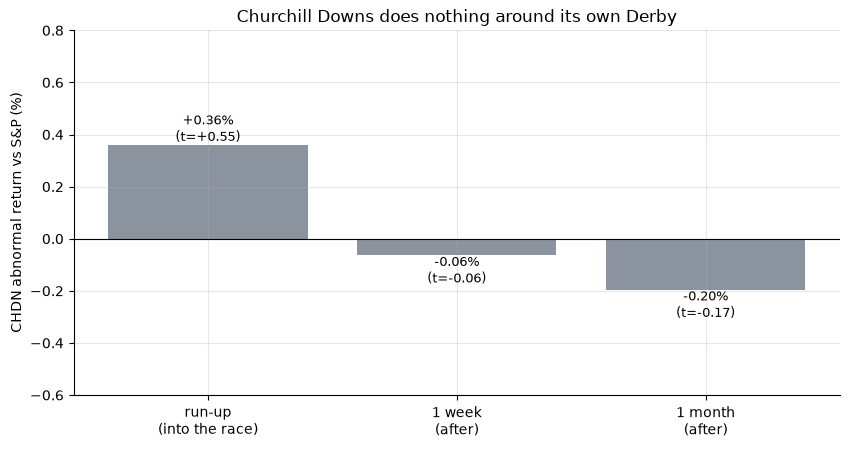

CHDN run-up 0.359 week -0.063 month -0.195


In [2]:
if HAVE_REAL:
    ru = st.one_sample_t(CHDN['ar_runup'].values)['mean']*100
    wk = st.one_sample_t(CHDN['ar_week'].values)['mean']*100
    mo = st.one_sample_t(CHDN['ar_month'].values)['mean']*100
    ts = [st.one_sample_t(CHDN[c].values)['t'] for c in ('ar_runup','ar_week','ar_month')]
else:
    ru, wk, mo = R['ch_ru_mean'], R['ch_wk_mean'], R['ch_mo_mean']
    ts = [R['ch_ru_t'], R['ch_wk_t'], R['ch_mo_t']]
labels = ['run-up\n(into the race)', '1 week\n(after)', '1 month\n(after)']
fig, ax = plt.subplots(figsize=(8.6, 4.6))
bars = ax.bar(labels, [ru, wk, mo], color=[GREY, GREY, GREY])
for b, v, t in zip(bars, [ru, wk, mo], ts):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('CHDN abnormal return vs S&P (%)')
ax.set_ylim(-0.6, 0.8)
ax.set_title('Churchill Downs does nothing around its own Derby')
plt.tight_layout(); plt.show()
print('CHDN run-up', round(ru,3), 'week', round(wk,3), 'month', round(mo,3))

A tiny positive drift into the race (**+0.36%**, *t* = 0.55), flat-to-negative after, every *t*-stat comfortably under 1, every hit rate a coin flip. The most directly-exposed instrument on the board, with a full price history back to the 1990s, produces the cleanest possible *nothing*.

> One honest caveat, and it points the *wrong* way for the folklore: CHDN in 2000 was basically a racetrack; CHDN today is a diversified casino + online-betting company for which the Derby is a shrinking slice of revenue. So the direct exposure was *strongest* early in our sample — and it still shows nothing.

**Now the market. Is Derby week — the "Sell in May" line — a real seasonal?**

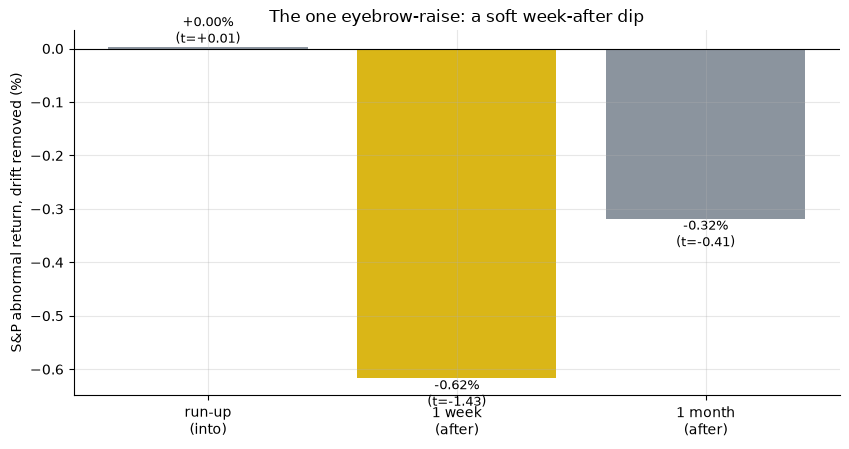

market run-up 0.003 week -0.617 month -0.319


In [3]:
if HAVE_REAL:
    ru = st.one_sample_t(MKT['ar_runup'].values)['mean']*100
    wk = st.one_sample_t(MKT['ar_week'].values)['mean']*100
    mo = st.one_sample_t(MKT['ar_month'].values)['mean']*100
    ts = [st.one_sample_t(MKT[c].values)['t'] for c in ('ar_runup','ar_week','ar_month')]
else:
    ru, wk, mo = R['mk_ru_mean'], R['mk_wk_mean'], R['mk_mo_mean']
    ts = [R['mk_ru_t'], R['mk_wk_t'], R['mk_mo_t']]
labels = ['run-up\n(into)', '1 week\n(after)', '1 month\n(after)']
fig, ax = plt.subplots(figsize=(8.6, 4.6))
cols = [RED if abs(t)>=2 else (AMBER if abs(t)>=1 else GREY) for t in ts]
bars = ax.bar(labels, [ru, wk, mo], color=cols)
for b, v, t in zip(bars, [ru, wk, mo], ts):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='top' if v<0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('S&P abnormal return, drift removed (%)')
ax.set_title('The one eyebrow-raise: a soft week-after dip')
plt.tight_layout(); plt.show()
print('market run-up', round(ru,3), 'week', round(wk,3), 'month', round(mo,3))

Here's the whole study's one interesting number: in the week *after* the Derby, the S&P is **-0.62%** below its own average day (*t* = -1.43), up only 7 of 25 years. That's the "Sell in May" texture, and it's genuinely negative — but it **doesn't clear the bar even raw**. So we do the one test that matters: is a dip that deep actually unusual, or does a *random* week do it too?

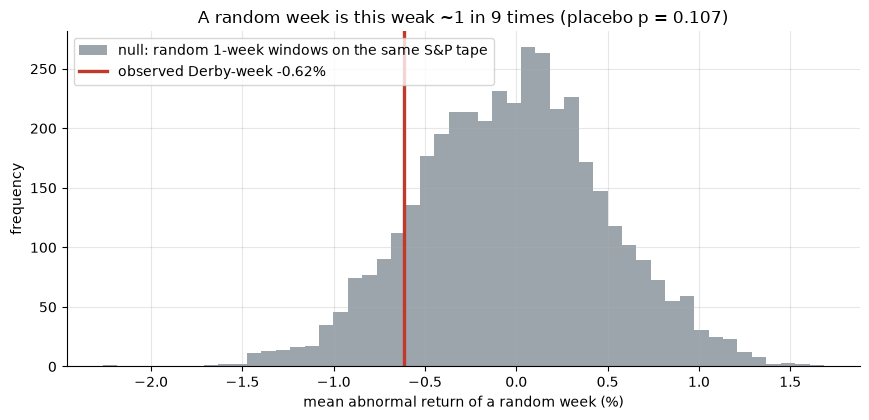

observed -0.617%, placebo mean +0.001% (sd 0.501%), left-tail p = 0.107


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'market', 'ar_week', k=5, entry_offset=0,
                           tail='left', n_seeds=4, n_draws_per_seed=200)
    obs = pl['obs']*100
    rng = np.random.default_rng(733)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['mk_wk_mean']
    rng = np.random.default_rng(733)
    draws = rng.normal(R['pl_mk_wk_plmean'], R['pl_mk_wk_plsd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random 1-week windows on the same S&P tape')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Derby-week {obs:+.2f}%')
ax.set_xlabel('mean abnormal return of a random week (%)'); ax.set_ylabel('frequency')
ax.set_title(f'A random week is this weak ~1 in 9 times (placebo p = {R["pl_mk_wk_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['mk_wk_mean']:+.3f}%, placebo mean {R['pl_mk_wk_plmean']:+.3f}% "
      f"(sd {R['pl_mk_wk_plsd']:.3f}%), left-tail p = {R['pl_mk_wk_p']:.3f}")

The Derby-week dip sits comfortably *inside* the luck cloud: a random week on the same tape is at least this weak about **1 time in 9** (*p* = 0.107). It's a shadow of "Sell in May," not a Derby effect, and not something the desk would ever certify.

**But wait — doesn't one version of this clear *t* ≥ 2? Let's chase it down.**

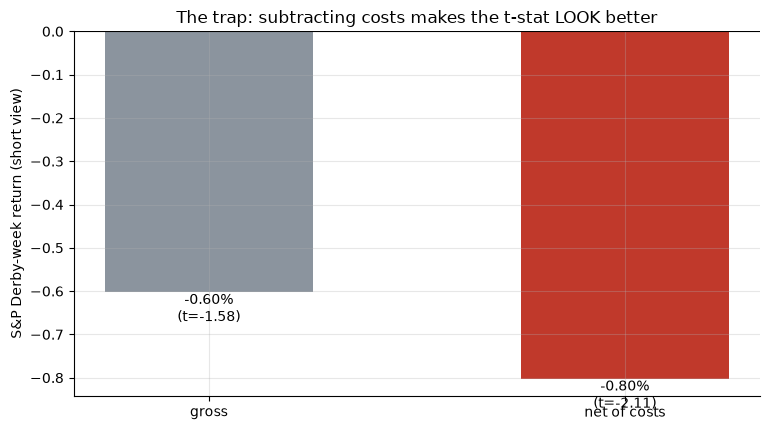

gross -0.60% (t=-1.58) -> net -0.80% (t=-2.11)


In [5]:
g, gt = R['mk_wk_cap_g'], R['mk_wk_cap_gt']
n, nt = R['mk_wk_cap_n'], R['mk_wk_cap_t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
bars = ax.bar(['gross', 'net of costs'], [g, n], color=[GREY, RED], width=.5)
for b, v, t in zip(bars, [g, n], [gt, nt]):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='top', fontsize=10)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('S&P Derby-week return (short view)')
ax.set_title('The trap: subtracting costs makes the t-stat LOOK better')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}% (t={gt:+.2f}) -> net {n:+.2f}% (t={nt:+.2f})')

Here's the sleight of hand. The Derby-week return is already **-0.60%** (a dip). *Subtract* a round trip of costs and it becomes **-0.80%** — a bigger negative number, so its *t*-stat gets *more* extreme (**-2.11**), sailing past the −2 line. For a *real* tradable edge, costs make the *t* worse, not better; here they flatter it, which is the tell. And its own placebo (*p* = 0.111) says the underlying dip was noise anyway. To "harvest" it you'd short the S&P for one week, 25 years running, paying spread and borrow for a coin flip. That's a mirage, not a strategy.

## 5 · The verdict

- **Signal — None.** CHDN, the directly-exposed name, is flat everywhere (every |*t*| < 1) with full tape coverage; the market's only whisper (the week-after dip) misses the bar raw and fails its drift-neutral placebo.
- **Tradability — Mirage.** The only cut that crosses |*t*| ≥ 2 is an arithmetic artifact of charging costs against an already-negative number, and it dies under its own placebo.
- **"Sell in May?" — Not supported.** The Derby-week dip is real in *sign* but inside the luck cloud and fragile to a single year — the folklore's May boundary is not a market turn you could trade.

## 6 · Going further 🚪

- **This is the value of a *clean* null.** Most folklore debunks come with an asterisk ("…but the data was thin"). Not here: the most-exposed stock, full history, no survivorship funnel — and still nothing. When even the ideal test setup shows a flat line, the folklore is just folklore.
- **The costs-flatter-the-*t* trap is the transferable lesson.** Any time a "short this seasonal" edge gets *more* significant after costs, you're charging costs against a negative return — check the placebo before you believe it.
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (same machinery, but a survivorship story), the [plane-crash effect](../../707-plane-crash-effect/) (market + directly-exposed basket, a *negative* shock), the [Super Bowl indicator](../../158-super-bowl/) and [World Cup effect](../../235-world-cup-effect/).

*Think there's a real Derby edge — in betting-handle data, in intraday moves, in a cleaner gaming basket? Find a net, replicated, placebo-surviving version and we'll publish the teardown.*